In [3]:
#Read Ajivit's BCM maps and write them in a format + directory structure needed by pollux:
import numpy as np
import healpy as hp
#import random
#import input
import matplotlib.pyplot as plt
import h5py
import healsparse

In [13]:

n_slices=51
nshells=51
dmo = False
nside = 8192
seed = 0

hpmap_weight = hp.fitsfunc.read_map('../../FullSky_weight.fits', field=0,nest=False, partial=False, hdu=1, h=False, verbose=True, memmap=True)
unmask = np.where(hpmap_weight > 0)[0]
#mask_bad= hp.pixelfunc.mask_bad(hpmap_weight, badval=0)
 
for plane in range(20,21):
#for plane in range(0,n_slices):


    #Read maps:
    lens_str = str(plane).zfill(2)
    #filename = '/pscratch/sd/a/avijit97/BCM/HACC/params_dependencies/full_lightcone/Mc/1e14/nshells_51/nshells_'+str(nshells)+'_imap_{}/baryonified_shells_v11.h5'.format(lens_str)
    filename = '/pscratch/sd/a/avijit97/BCM/HACC/params_dependencies/full_lightcone/Mc/2e14/nshells_51/nshells_'+str(nshells)+'_imap_{}/baryonified_shells_v11.h5'.format(lens_str)

    with h5py.File(filename,'r') as f:
        #print('h5py file fields:',f.keys())
        nobaryon_shells = np.array(f['nobaryon_shells'])
        diff_shells = np.array(f['diff_shells'])
        #baryon_shells = nobaryon_shells+diff_shells
    
        if(dmo):
            hpmap_density=nobaryon_shells
        else:
            hpmap_density=nobaryon_shells+diff_shells 

    #Map already in ring format:

    #Apply mask:
    hpmap_density+=np.abs(hpmap_weight-1)*hp.UNSEEN
    
    #Convert to NESTED
    hpmap_density_nested = hp.reorder(hpmap_density, r2n = True)
     
    #Write maps:
    nside_coverage = 32
    dtype = np.float32
    file_out = '/global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso/shell_hacc_seed'+str(seed)+'_nside8192_imap'+str(lens_str)+'.fits'
    
    hsp = healsparse.HealSparseMap.make_empty(nside_coverage, nside, dtype)
    hsp.update_values_pix(unmask, hpmap_density_nested[0][hp.ring2nest(8192, unmask)].astype(dtype), nest=True)
    hsp.write(file_out, clobber=True, format='fits', nocompress=True)



/tmp/ipykernel_1405986/932051583.py:7: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  hpmap_weight = hp.fitsfunc.read_map('../../FullSky_weight.fits', field=0,nest=False, partial=False, hdu=1, h=False, verbose=True, memmap=True)


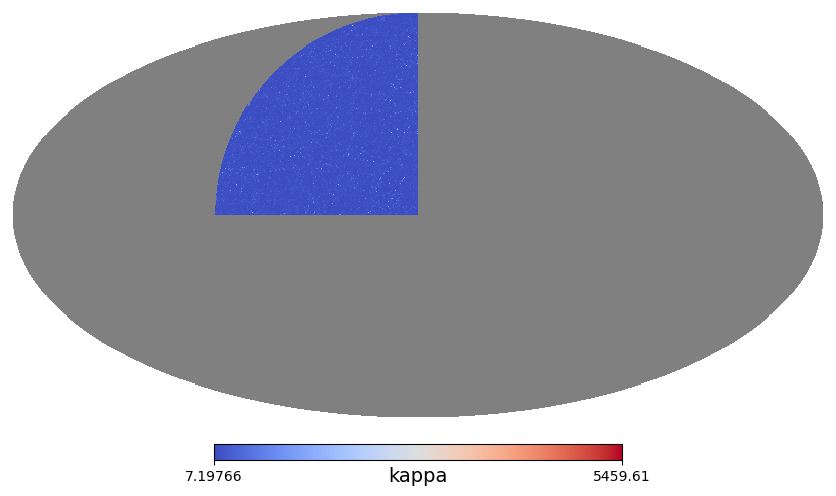

In [17]:
#read test
nside_c = 32
a = healsparse.HealSparseMap.read('/global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso/shell_hacc_seed'+str(seed)+'_nside8192_imap'+str(lens_str)+'.fits')
sdens = a.generate_healpix_map()

# turn masked pixels to zero.
#sdens[sdens<-1.0e+30]=0
hp.mollview(sdens,
            unit='kappa', cmap=plt.cm.coolwarm,
            cbar=True, title='', norm=None
            , nest=False
            )
plt.show()

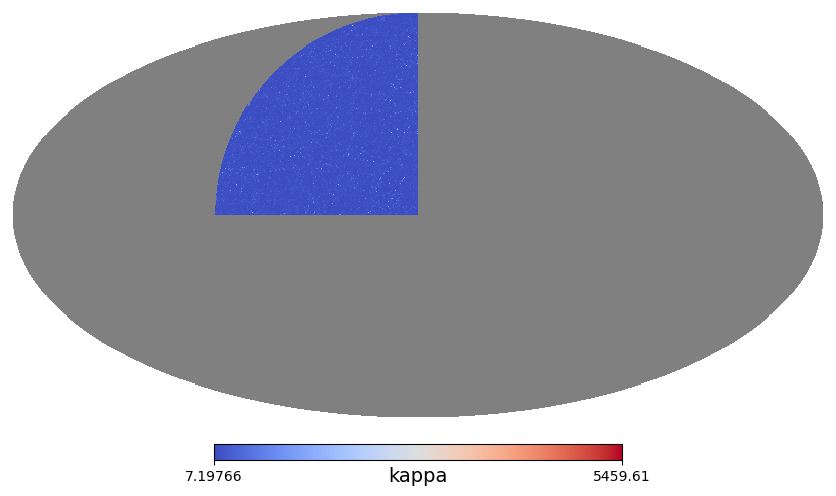

In [16]:
#hpmap_density=nobaryon_shells+diff_shells 
#hpmap_density+=np.abs(hpmap_weight-1)*hp.UNSEEN
#hpmap_density_nested = hp.reorder(hpmap_density, r2n = True)

hp.mollview(hpmap_density_nested[0],
            unit='kappa', cmap=plt.cm.coolwarm,
            cbar=True, title='', norm=None
            , nest=True
            )
plt.show()

In [100]:
!chmod g+xr /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/*/*

In [94]:
!echo ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/
!ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/
!echo ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den
!ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den
!echo ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso
!ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso

ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/
total 70
drwxrwx---  3 jharno lsst  4096 Mar 24 08:23 den
drwxrws---  2 jharno lsst  4096 Nov 21 01:56 fullsky_den
drwxrws---  3 jharno lsst 32768 Feb 12 08:51 GalCat
drwxrwsr-x+ 2 jharno lsst  4096 Sep  4  2024 kappa
drwxrws---  2 jharno lsst  4096 Feb 26 07:07 kappa-KS
drwxrws---  2 jharno lsst  4096 Sep 23 01:07 shear
drwxrws---  2 jharno lsst  4096 Nov 21 07:49 tidalfield
ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den
total 32
drwxr-x--- 2 jharno lsst 16384 Mar 24 11:13 shells_z51_subsampleauto_groupiso
ls -l /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso
total 160469664
-rw-rwx--- 1 jharno lsst 1610982720 Mar 24 10:14 shell_hacc_seed0_nside8192_imap00.fits
-rw-rwx--- 1 jharno lsst 1610982720 Mar 24 10:15 shell_hacc_seed0_nside8192_imap01.fits
-rw-rwx--- 1 jharno lsst 1610982720 Mar 24 10:16 shell_hacc_seed0_nside8192_imap02.

In [101]:
!chown -R :lsst /global/cfs/cdirs/desc-wl/projects/wl-massmap/IA-infusion/BCM/dmb/den/shells_z51_subsampleauto_groupiso


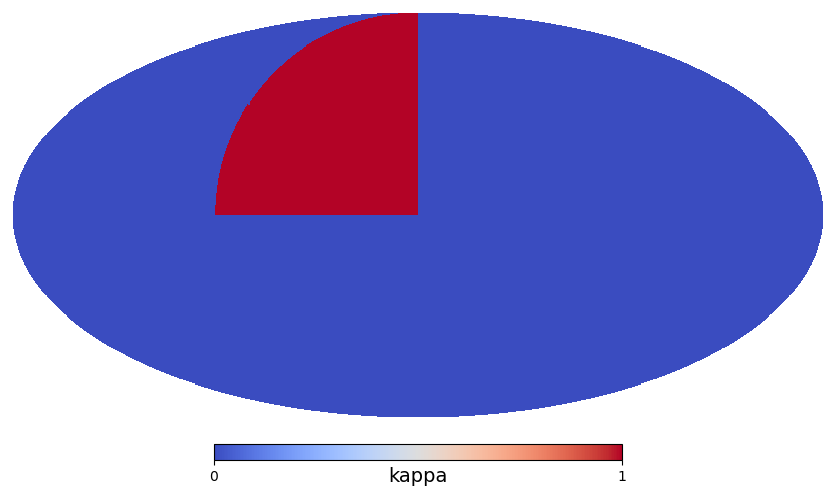

In [114]:
#min(hpmap_weight[unmask] )
#ring2nest(nside, ipix)
hpmap_weight_nested = hp.reorder(hpmap_weight, r2n = True)
hp.mollview(hpmap_weight_nested,
            unit='kappa', cmap=plt.cm.coolwarm,
            cbar=True, title='', norm=None
            , nest=True
            )
plt.show()

In [119]:
min( )

1.0

In [78]:
mask_bad= hp.pixelfunc.mask_bad(hpmap_weight, badval=0)

In [79]:
mask_bad

array([False,  True,  True, ...,  True,  True,  True])

In [63]:
mask = hp.ma(mask_bad)

In [66]:
mask_map = hp.ma(hpmap_weight, badval=0)

In [67]:
mask_map

masked_array(data=[1.0, --, --, ..., --, --, --],
             mask=[False,  True,  True, ...,  True,  True,  True],
       fill_value=0.0,
            dtype=float32)

In [69]:
mask_map[mask_bad] = hp.UNSEEN

In [70]:
mask_map

masked_array(data=[1.0, -1.637499996306027e+30, -1.637499996306027e+30,
                   ..., -1.637499996306027e+30, -1.637499996306027e+30,
                   -1.637499996306027e+30],
             mask=[False, False, False, ..., False, False, False],
       fill_value=0.0,
            dtype=float32)

In [73]:
np.shape(hpmap_density)

(1, 805306368)

In [75]:
np.shape(hpmap_weight)

(805306368,)

In [76]:
masked_map = hp.ma(hpmap_density, badval=0)


In [77]:
masked_map

masked_array(data=[[--, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --, --, --, --, --,
                    --, --, --, --, --, --, --, --, --]],
             mask=[[ True,  True,  True, ...,  True,  True,  True]],
       fill_value=0.0,
            dtype=float32)

In [82]:
hp.UNSEEN

-1.6375e+30

In [87]:
np.abs(hpmap_weight-1)*hp.UNSEEN


array([-0.0000e+00, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
       -1.6375e+30, -1.6375e+30], dtype=float32)

In [88]:
hpmap_density+=np.abs(hpmap_weight-1)*hp.UNSEEN


In [89]:
hpmap_density

array([[ 0.0000e+00, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]], dtype=float32)